In [1]:
from langgraph.graph import START, StateGraph, END
from typing import TypedDict, Literal

In [2]:
class Quadstate(TypedDict):
    a : int
    b : int
    c : int
    
    equation : str
    discriminant : float
    result : str
    

In [3]:
def show_equation(state : Quadstate):
    
    equation = f'{state['a']}x2{state['b']}x{state['c']}'
    
    return {'equation':equation}

def show_discriminant(state : Quadstate):
    
    discriminant = state['b']**2 - (4*state['a']*state['c'])
    
    return {'discriminant': discriminant}

def real_roots(state : Quadstate):
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])
    result = f'The roots are {root1} and {root2}'
    
    return {'result': result}

def repeated_roots(state : Quadstate):
    
    root = (-state['b']/(2*state['a']))
    
    result = f'The only root are {root}'
    
    return {'result': result}

def no_real_roots(state : Quadstate):
    
    result = f'No real roots'
    
    return {'result': result}

def check_condition(state : Quadstate)-> Literal['real_roots', 'no_real_roots','repeated_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else :
        return 'no_real_roots'

In [5]:
graph = StateGraph(Quadstate)

#creating nodes of the graph
graph.add_node('show_equation', show_equation)
graph.add_node('show_discriminant', show_discriminant)
graph.add_node('no_real_roots', no_real_roots)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)

#creating the edges
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'show_discriminant')
graph.add_conditional_edges('show_discriminant',check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('no_real_roots', END)
graph.add_edge('repeated_roots', END)

workflow = graph.compile()

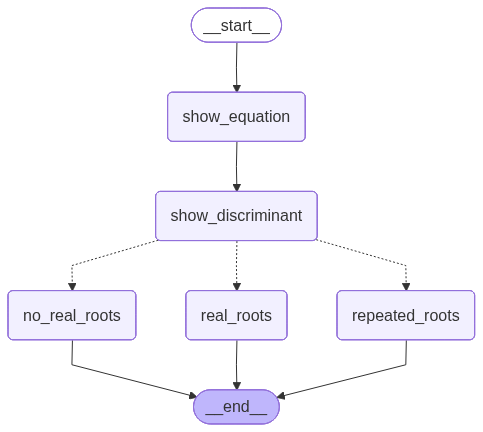

In [6]:
workflow

In [11]:
initial_state = {
    'a' : -3,
    'b' : -4,
    'c' : +12 
}

workflow.invoke(initial_state)

{'a': -3,
 'b': -4,
 'c': 12,
 'equation': '-3x2-4x12',
 'discriminant': 160,
 'result': 'The roots are -2.7748517734455866 and 1.441518440112253'}